# IBM HR Employee Attrition Analysis
**Author:** Vishwas Chaudhary  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Dataset:** IBM HR Analytics Dataset (Kaggle) — 1,470 employees, 35 features

## Objective
Analyse employee attrition patterns at IBM to identify the key drivers of 
employee turnover and provide actionable business recommendations to the HR team.

## Key Finding
The overall attrition rate is **16.12%** — above the industry benchmark of 
10–12%. Overtime, low compensation, and poor job satisfaction are the 
strongest predictors of attrition.

In [1]:
# Importing Liabraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Loading the dataset
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
# Data overview

print("Column names and data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Column names and data types:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears  

In [4]:
# Cleaning and preparing data

# Drop Columns with no analytical value
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'])

# Convert Attrition to numeric (1 = left, 0 = stayed)
# This makes it easy to calculate attrition rates later

df['AttritionNum'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

print("Remaining columns:", df.shape[1])
print("\nAttrition breakdown:")
print(df['Attrition'].value_counts())
print("\nOverall attrition rate:", round(df['AttritionNum'].mean() * 100, 2), "%")

Remaining columns: 33

Attrition breakdown:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Overall attrition rate: 16.12 %


## 1. Attrition by Department
Sales has the highest attrition rate at **20.63%**, followed by Human Resources 
at **19.05%**. Research & Development is comparatively stable at **13.84%**. 
Sales teams are the highest priority for retention intervention.

Attrition rate by Department:
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: AttritionNum, dtype: float64


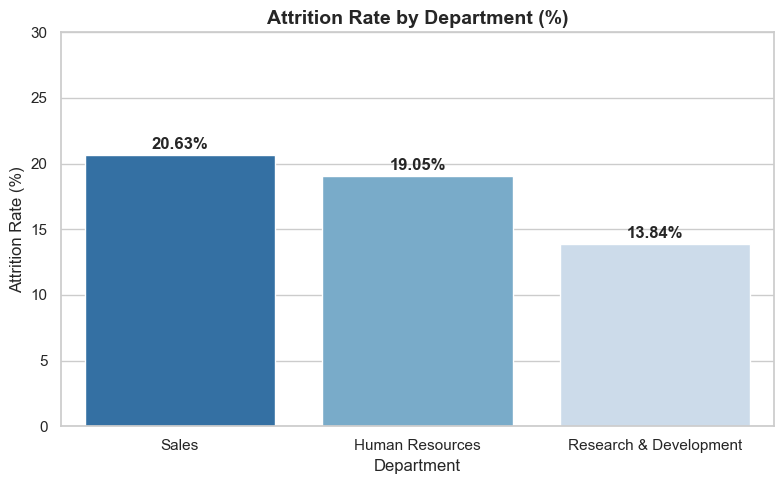

In [5]:
# Attrition by Department
dept_attrition = df.groupby('Department')['AttritionNum'].mean() * 100
dept_attrition = dept_attrition.round(2).sort_values(ascending=False)

print("Attrition rate by Department:")
print(dept_attrition)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=dept_attrition.index, y=dept_attrition.values, hue=dept_attrition.index, palette='Blues_r', legend=False)
plt.title('Attrition Rate by Department (%)', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0,30)
for i, v in enumerate(dept_attrition.values):
    plt.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/chart1_dept_attrition.png', dpi=150)
plt.show()

## 2. Impact of Overtime on Attrition
Employees working overtime leave at **30.53%** — nearly 3x the rate of those 
who don't (10.44%). Overtime is the single strongest attrition predictor in 
this dataset.

Attrition rate by Overtime:
OverTime
No     10.44
Yes    30.53
Name: AttritionNum, dtype: float64


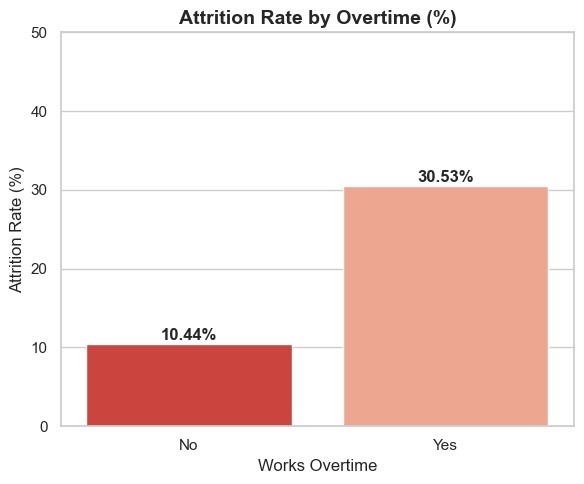

In [6]:
# Attrition by Overtime

overtime_attrition = df.groupby('OverTime')['AttritionNum'].mean() * 100
overtime_attrition = overtime_attrition.round(2)

print("Attrition rate by Overtime:")
print(overtime_attrition)

# Plot
plt.figure(figsize=(6, 5))
sns.barplot(x=overtime_attrition.index, y=overtime_attrition.values, hue=overtime_attrition.index, palette='Reds_r', legend=False)
plt.title('Attrition Rate by Overtime (%)', fontsize=14, fontweight='bold')
plt.xlabel('Works Overtime')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 50)
for i, v in enumerate(overtime_attrition.values):
    plt.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/chart2_overtime_attrition.png', dpi=150)
plt.show()

## 3. Monthly Income vs Attrition
Employees who left had a median monthly income of **$3,202** compared to 
**$5,204** for those who stayed — a 38% gap. Low compensation is a significant 
driver of early-career attrition.

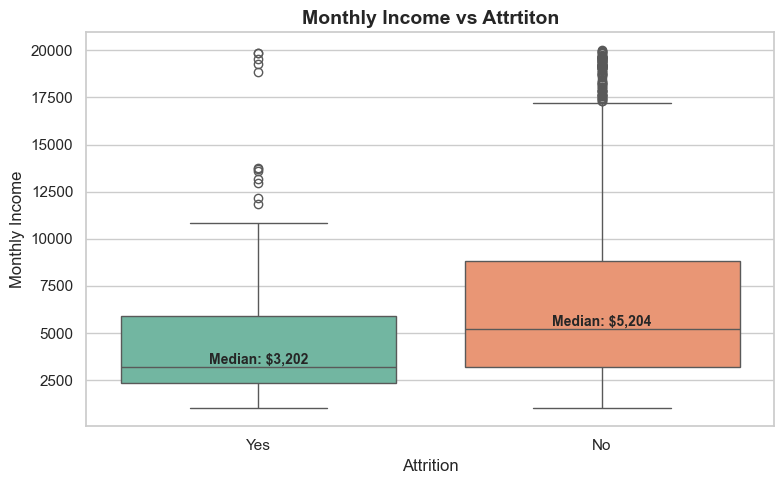

In [7]:
# Income vs Attrition

plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, hue='Attrition', palette='Set2', legend=False)
plt.title('Monthly Income vs Attrtiton', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')

# Add median labels
for i, group in enumerate(['Yes', 'No']):
    median = df[df['Attrition'] == group]['MonthlyIncome'].median()
    plt.text(i, median + 200, f'Median: ${median:,.0f}', ha ='center', fontweight='bold', fontsize=10)
    
plt.tight_layout()
plt.savefig('../notebooks/chart3_income_attrition.png', dpi=150)
plt.show()

## 4. Attrition by Job Satisfaction
Employees with the lowest satisfaction (level 1) leave at **22.84%** — double 
the rate of highly satisfied employees (11.33%). The biggest risk jump occurs 
at the lowest satisfaction level.

Attrition rate by Job Satisfaction level:
JobSatisfaction
1    22.84
2    16.43
3    16.52
4    11.33
Name: AttritionNum, dtype: float64


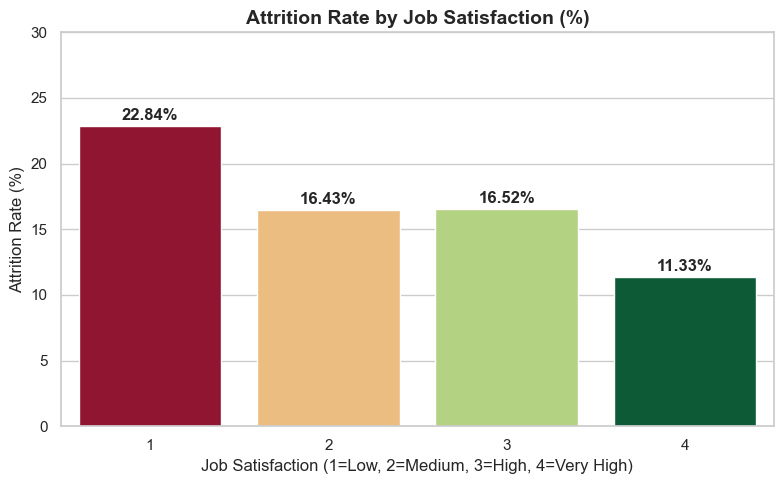

In [8]:
# Attrition by Job Satisfaction
# Job Satisfaction is rated 1-4 (1=Low, 2=Medium, 3=High, 4=Very High)
satisfaction_attrition = df.groupby('JobSatisfaction')['AttritionNum'].mean() * 100
satisfaction_attrition = satisfaction_attrition.round(2)

print("Attrition rate by Job Satisfaction level:")
print(satisfaction_attrition)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=satisfaction_attrition.index, y=satisfaction_attrition.values, hue=satisfaction_attrition.index, palette='RdYlGn', legend=False)
plt.title('Attrition Rate by Job Satisfaction (%)', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction (1=Low, 2=Medium, 3=High, 4=Very High)')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 30)
for i, v in enumerate(satisfaction_attrition.values):
    plt.text(i, v +0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/chart4_satisfaction_attrition.png', dpi=150)
plt.show()

## 5. Attrition by Tenure
Attrition is highest in the first two years — **36.36% at year 0** and 
**34.50% at year 1**. After year 5, attrition drops consistently below the 
overall average. The onboarding period is the most critical retention window.

Attrition rate by Years at Company:
YearsAtCompany
0      36.36
1      34.50
2      21.26
3      15.62
4      17.27
5      10.71
6      11.84
7      12.22
8      11.25
9       9.76
10     15.00
11      6.25
12      0.00
13      8.33
14     11.11
15      5.00
16      8.33
17     11.11
18      7.69
19      9.09
20      3.70
21      7.14
22      6.67
23     50.00
24     16.67
25      0.00
26      0.00
27      0.00
29      0.00
30      0.00
31     33.33
32     33.33
33     20.00
34      0.00
36      0.00
37      0.00
40    100.00
Name: AttritionNum, dtype: float64


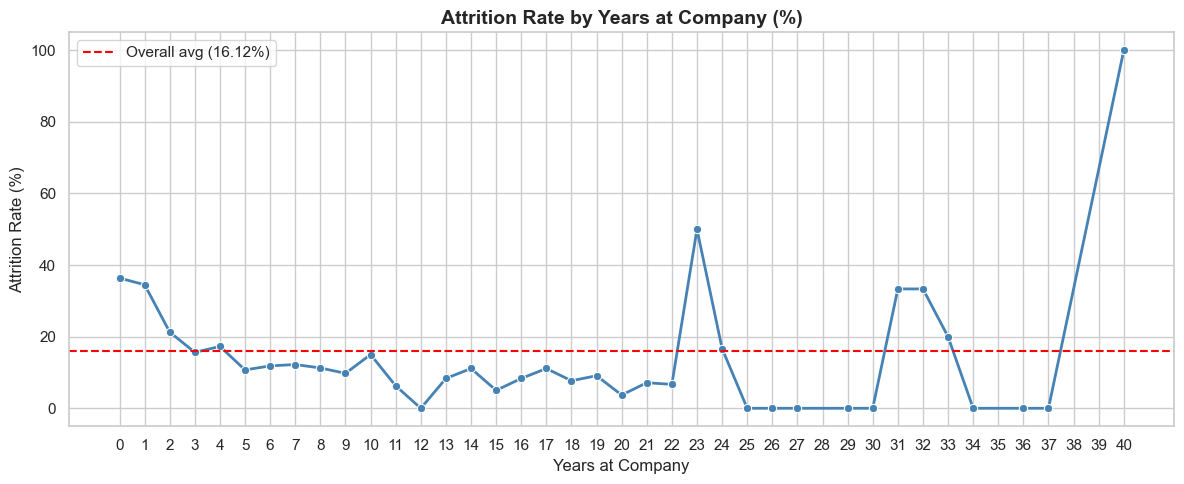

In [9]:
# Attrition by Years at Company
years_attrition = df.groupby('YearsAtCompany')['AttritionNum'].mean() * 100
years_attrition = years_attrition.round(2)

print("Attrition rate by Years at Company:")
print(years_attrition)

# Plot
plt.figure(figsize=(12, 5))
sns.lineplot(x=years_attrition.index, y=years_attrition.values, marker='o', color='steelblue', linewidth=2)
plt.title('Attrition Rate by Years at Company (%)', fontsize=14, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.xticks(range(0, df['YearsAtCompany'].max() + 1))
plt.axhline(y=16.12, color='red', linestyle='--', linewidth=1.5, label='Overall avg (16.12%)')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/chart5_years_attrition.png', dpi=150)
plt.show()

## 6. Attrition by Marital Status
Single employees leave at **25.53%** — more than double the rate of divorced 
(10.09%) and married (12.48%) employees. Single employees have fewer financial 
commitments and are more mobile in their career decisions.

Attrition rate by Marital Status:
MaritalStatus
Divorced    10.09
Married     12.48
Single      25.53
Name: AttritionNum, dtype: float64


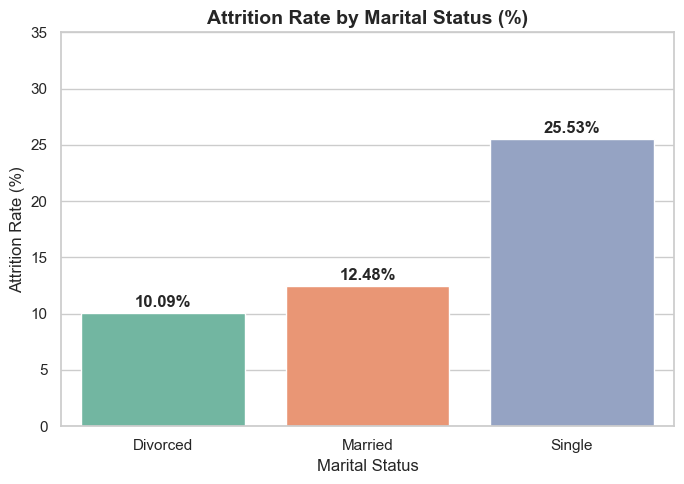

In [10]:
# Attrition by Marital Status
marital_attrition = df.groupby('MaritalStatus')['AttritionNum'].mean() * 100
marital_attrition = marital_attrition.round(2)

print("Attrition rate by Marital Status:")
print(marital_attrition)

# Plot
plt.figure(figsize=(7, 5))
sns.barplot(x=marital_attrition.index, y=marital_attrition.values, hue=marital_attrition.index, palette='Set2', legend=False)
plt.title('Attrition Rate by Marital Status (%)', fontsize=14, fontweight='bold')
plt.xlabel('Marital Status')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 35)
for i, v in enumerate(marital_attrition.values):
    plt.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/chart6_marital_attrition.png', dpi=150)
plt.show()

In [14]:
# Summary of Key Findings
summary = {
    'Finding': [
        'Overall Attrition Rate',
        'Highest Attrition Department',
        'Overtime: Yes vs No',
        'Low vs High Job Satisfaction',
        'Single vs Married Employees',
        'Highest Risk Tenure Period',
        'Median Income: Left vs Stayed'
    ],
    'Value': [
        '16.12%',
        'Sales (20.63%)',
        '30.53% vs 10.44%',
        '22.84% vs 11.33%',
        '25.53% vs 12.48%',
        'Year 0-1 (35%+ attrition)',
        '$3,202 vs $5,204'
    ],
    'Business Implication': [
        'Above industry benchmark of 10-12%',
        'Sales team needs urgent attention',
        'Overtime is the strongest attrition predictor',
        'Low satisfaction doubles attrition risk',
        'Single employees are highest flight risk',
        'Onboarding and early engagement is critical',
        'Low pay is driving early-career exits'
    ]
}

summary_df = pd.DataFrame(summary)
print("=" * 101)
print("KEY FINDINGS - IBM HR ATTRITION ANALYSIS")
print("=" * 101)
print(summary_df.to_string(index=False))
print("=" * 101)

KEY FINDINGS - IBM HR ATTRITION ANALYSIS
                      Finding                     Value                          Business Implication
       Overall Attrition Rate                    16.12%            Above industry benchmark of 10-12%
 Highest Attrition Department            Sales (20.63%)             Sales team needs urgent attention
          Overtime: Yes vs No          30.53% vs 10.44% Overtime is the strongest attrition predictor
 Low vs High Job Satisfaction          22.84% vs 11.33%       Low satisfaction doubles attrition risk
  Single vs Married Employees          25.53% vs 12.48%      Single employees are highest flight risk
   Highest Risk Tenure Period Year 0-1 (35%+ attrition)   Onboarding and early engagement is critical
Median Income: Left vs Stayed          $3,202 vs $5,204         Low pay is driving early-career exits


## Business Recommendations

1. **Reduce overtime in Sales** — with 20.63% department attrition and overtime 
driving a 3x higher leaving rate, Sales is the highest risk area.

2. **Review entry-level compensation** — employees leaving earn 38% less than 
those staying. A salary review for junior roles would directly address the 
biggest attrition segment.

3. **Strengthen onboarding programs** — over a third of employees leave within 
their first year. Structured mentorship and 90-day check-ins could significantly 
reduce early attrition.

4. **Conduct satisfaction surveys and act on results** — low satisfaction 
doubles attrition risk. Regular pulse surveys with visible follow-up action 
would address this directly.

5. **Create targeted retention programs for single employees** — career growth 
paths, learning opportunities, and community building appeal more to this group 
than compensation alone.